In [ ]:
from os import read
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder,OneHotEncoder

df = pd.read_excel("sample_data/NBT-SmallSet.xlsx")
df.head()

,TheatreRoom,admission_type,SessionIDdesc,intended_management,actual_proc_1_procedure_code,ProcedureDescription,theatre_notes,ExpectedDurationMins,into_theatre,anaesthetic_start_time,...,recovery_time,operation_length_mins,sex_national_code,age_at_operation,ASAScore,PriorityLevelCode,anaesthetic_desc,listing_cons_code,theat_surg_1_national_code,theat_anae_1_national_code
0,PLASTIC MINOR 2,11,TH 26 AM P Consultant (Plastic Surgery),2.0,S069,Unspecified other excision of lesion of skin,60mins/day case/LA/ 5mm WLE R abdo scar )(in-s...,60.0,00:20:00,00:20:00,...,00:43:00,19.0,2.0,68.0,1.0,P2,LA (Surgeon),A000012,C4090155,NaN
1,PARKVIEW TH02,11,TH2 (2SD) A Harris (Urology),2.0,M653,Endoscopic resection of prostate NEC,TURP DC GA P3 Xray no Comments = Retentio...,120.0,00:15:00,00:15:00,...,NaN,92.0,1.0,72.0,2.0,P3,LA (Surgeon),C7016369,C7016369,C7042030
2,BRUNEL TH 11,11,TH11(2SD) Mr A Kiszely (Trauma and Orthopaedics),2.0,Z724,Carpal bone NEC,Right Trapeziectomy +/- LRTI 90 mins....,120.0,00:58:00,00:58:00,...,NaN,60.0,2.0,70.0,2.0,P4,GA,C7136326,C7136326,7038820
3,PLASTIC MINOR 2,11,TH 26 PM P Consultant (Plastic Surgery),2.0,S069,Unspecified other excision of lesion of skin,60mnins/day case/LA/ excision 4mm margin dorsu...,60.0,00:12:00,00:12:00,...,00:47:00,28.0,2.0,85.0,2.0,NaN,LA (Surgeon),A000012,C7040583,NaN
4,BRUNEL TH 15,11,TH15 (3SD) H GILBERT (Urology),2.0,M455,Diagnostic endoscopic examination of bladder u...,Rigid cystoscopy under GA +/- Biopsy DC GA....,48.0,00:51:00,00:51:00,...,NaN,27.0,2.0,74.0,3.0,P2,GA,C3015366,C3398948,C3492598


In [ ]:
import pandas as pd
import re
thsd = []
tsd = []
def extract_last_word_in_parentheses(text,procedure):
    text = str(text)
    extracted_words = []

    # Start from the end of the string and look for the last pair of parentheses
    i = len(text) - 1
    while i > 0:
        if text[i] == ')':  # Look for closing parenthesis
            j = i - 1  # Start searching for the opening parenthesis
            while j >= 0 and text[j] != '(':  # Look for the matching opening parenthesis
                j -= 1
            if j >= 0 and text[j] == '(':  # Found the matching opening parenthesis
                extracted_words.append(text[j + 1:i].lower())  # Extract the content between parentheses
                if(text[j + 1:i]=='3SD'):
                  thsd.append(text.lower())
                if(text[j + 1:i]=='2SD'):
                  tsd.append(text.lower())
                break  # Only extract the first (last) parenthesis pair
        i -= 1  # Move to the next character from the end

    # Return extracted word or None if no words are found
    if extracted_words:
      return extracted_words[0]
    else:
      if procedure in [
        'Elective lower uterine segment caesarean delivery',
        'Evacuation of products of conception from uterus NEC'
    ]:
        return 'Obstetrics and Gynaecology'

    if procedure in [
        'Drainage of kidney NEC',
        'Unspecified diagnostic endoscopic examination of bladder'
    ]:
        return 'urology'

    if procedure == 'Percutaneous transluminal angioplasty of artery':
        return 'vascular surgery'

    # SessionIDdesc direct mapping
    if text == 'Trauma and Orthopaedics':
        return 'trauma and orthopaedics'

    if text == 'Radiology':
        return 'radiology'

    if text == 'KPI OneStop Consultant':
        return 'plastic surgery'

    return None

# Assuming df is your DataFrame
df['extracted_words'] = df.apply(
    lambda row: extract_last_word_in_parentheses(
        row['SessionIDdesc'],
        row['ProcedureDescription']
    ),
    axis=1
)

# Remove duplicates
df_unique = df.drop_duplicates(subset=['extracted_words'], inplace=False)

df['extracted_words'].unique()

array(['plastic surgery', 'urology', 'trauma and orthopaedics',
       'radiology', 'neurosurgery', 'gynaecology',
       'trauma & orthopaedics', 'non specific', 't&o', 'breast surgery',
       'vascular surgery', 'obs & gynae', 'cardiology', 'general surgery',
       ' orthopaedics', 'nephrology', 'bariatrics',
       'Obstetrics and Gynaecology', 'anaesthetics',
       'thoracic & respiratory', 'dermatology', 'colorectal surgery',
       'upper gi', 'renal', 'am', 'trauma  orthopaedics',
       'reg list, overseen by c.burt a.smith', '3sd', 'endo', 'pain',
       'obstetrics and gynaecology', 'obstetrics', 'burms', 'general',
       'orthopaedics', 'trauma and orthop', 'neurology',
       'general surgery hot list', 'colo-rectal', None,
       'robotic gynaecology', 'burns', 'trauma orthopaedics', 'spinal',
       'trauma and ortho', 'gastroenterology', '2sd', 'breast',
       'trauma & ortho', 'obstetrics ',
       '3sd) khan trauma and orthopaedics', 'vascular/gynae surgery',
    

In [ ]:
# thsd = []
# tsd = []

# def extract_specialty(row):
#     session_text = str(df['SessionIDdesc'])
#     procedure = str(df['ProcedureDescription'])

#     # -------- 1️⃣ Try extracting last parentheses content --------
#     i = len(session_text) - 1
#     while i > 0:
#         if session_text[i] == ')':
#             j = i - 1
#             while j >= 0 and session_text[j] != '(':
#                 j -= 1
#             if j >= 0:
#                 extracted = session_text[j + 1:i]

#                 if extracted == '3SD':
#                     thsd.append(session_text)
#                 if extracted == '2SD':
#                     tsd.append(session_text)

#                 return extracted
#         i -= 1

#     # -------- 2️⃣ If no parentheses found → apply rules --------

#     # Procedure-based rules
#     if procedure in [
#         'Elective lower uterine segment caesarean delivery',
#         'Evacuation of products of conception from uterus NEC'
#     ]:
#         return 'Obstetrics and Gynaecology'

#     if procedure in [
#         'Drainage of kidney NEC',
#         'Unspecified diagnostic endoscopic examination of bladder'
#     ]:
#         return 'Urology'

#     if procedure == 'Percutaneous transluminal angioplasty of artery':
#         return 'Vascular Surgery'

#     # SessionIDdesc direct mapping
#     if session_text == 'Trauma and Orthopaedics':
#         return 'Trauma and Orthopaedics'

#     if session_text == 'Radiology':
#         return 'Radiology'

#     if session_text == 'KPI OneStop Consultant':
#         return 'Plastic Surgery'

#     return None  # If nothing matches


# # Apply function row-wise
# df['extracted_words'] = df.apply(extract_specialty, axis=1)

# # Remove duplicates if needed
# df_unique = df.drop_duplicates(subset=['extracted_words'], inplace=False)

# # Show unique values
# print(df['extracted_words'].unique())


In [ ]:
df['intended_management'].value_counts()


,count
intended_management,
1.0,7599
2.0,7108
8.0,169
3.0,31
5.0,5
4.0,1


In [ ]:
df['extracted_words'].value_counts()

,count
extracted_words,
plastic surgery,2764
trauma and orthopaedics,2134
radiology,1994
urology,1501
non specific,1450
obs & gynae,1063
gynaecology,799
cardiology,684
neurosurgery,540


In [ ]:
df['ASAScore'].value_counts()
#usinbg the correlation matrix we will decide the attribut that will be used to fulfill the nulls on ASASCORE

,count
ASAScore,
2.0,6219
3.0,4241
1.0,2424
4.0,723
5.0,35
6.0,21
0.0,1


In [ ]:
df['PriorityLevelCode'].value_counts()

,count
PriorityLevelCode,
P2,3714
P3,1521
P4,1119
P1,1


In [ ]:
df['admission_type'].value_counts()

,count
admission_type,
11,7780
21,2480
12,1592
13,975
31,714
22,438
2D,281
2A,267
24,233


In [ ]:
import pandas as pd
import numpy as np

def calculate_row_duration(row):
    # 1. Highest Priority: Surgical Time (Incision to Closure)
    if not pd.isna(row['incision']) and not pd.isna(row['closure']):
        return (row['closure'] - row['incision']).total_seconds() / 60

    # 2. Second Priority: Theatre Time (Into to Out of Theatre)
    elif not pd.isna(row['into_theatre']) and not pd.isna(row['out_of_theatre']):
        return (row['out_of_theatre'] - row['into_theatre']).total_seconds() / 60

    # 3. Third Priority: Existing Length Column
    elif not pd.isna(row['operation_length_mins']):
        return row['operation_length_mins']

    # 4. Final Fallback: Anesthesia Start to Operation End
    elif not pd.isna(row['anaesthetic_start_time']) and not pd.isna(row['operation_end_time']):
        return (row['operation_end_time'] - row['anaesthetic_start_time']).total_seconds() / 60

    # If all data is missing
    else:
        return np.nan

# --- Applying to your DataFrame ---
# Ensure columns are datetime objects first
cols_to_fix = ['incision', 'closure', 'into_theatre', 'out_of_theatre',
               'anaesthetic_start_time', 'operation_end_time']

for col in cols_to_fix:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Create the new column using the logic above
df['calculated_duration'] = df.apply(calculate_row_duration, axis=1)

# Missing values

In [ ]:
df.isna().sum()

,0
TheatreRoom,0
admission_type,2
SessionIDdesc,0
intended_management,5
actual_proc_1_procedure_code,90
ProcedureDescription,90
theatre_notes,76
ExpectedDurationMins,214
into_theatre,0
anaesthetic_start_time,0


In [ ]:
df = df.dropna(subset=['admission_type','intended_management'])

In [ ]:
category_counts=df['theatre_notes'].value_counts()
filtered_counts = category_counts[category_counts > 10]
filtered_counts

,count
theatre_notes,
.,2484
....,1147
(mobile image intensifier needed)....,116
Cat 4 LSCS....,43
Biopsy of Liver....,34
(mobile image intensifier needed).,27
P2....,26
RADIOFREQUENCY CONTROLLED THERMAL DENERVATION OF SPINAL FACET JOINT OF LUMBAR VERTEBRA (mobile image intensifier needed)....,20
RALP M61.1 2WW MSS GA X-ray No....,20


In [ ]:

# df_no_parentheses = df[~df['SessionIDdesc'].str.contains(r'\(|\)', na=False)]

# # Print the result
# print(df_no_parentheses)

# # Save the result to a new Excel file (if needed)
# df_no_parentheses.to_excel('filtered_no_parentheses.xlsx', index=False)


           TheatreRoom admission_type  \
130        GYNAE TH 01             31   
171        GYNAE TH 01             11   
1720       GYNAE TH 01             11   
2096       GYNAE TH 01             11   
3350   PLASTIC MINOR 2             11   
4079       GYNAE TH 01             31   
4091       GYNAE TH 01             11   
4676       GYNAE TH 01             31   
4713       GYNAE TH 01             31   
4863       GYNAE TH 01             11   
5426   PLASTIC MINOR 2             11   
5584       GYNAE TH 01             11   
5687       GYNAE TH 01             11   
5713       GYNAE TH 01             11   
5767       GYNAE TH 01             11   
5810       GYNAE TH 01             31   
6198     COTSWOLD TH01             11   
6216     COTSWOLD TH01             11   
6426       GYNAE TH 02             11   
6444       GYNAE TH 02             11   
7087          IR LAB 4             81   
7464      BRUNEL TH 07             21   
7548      BRUNEL TH 07             21   
7719       GYNAE

# Encoding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14918 entries, 0 to 14917
Data columns (total 26 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   TheatreRoom                   14918 non-null  object        
 1   admission_type                14916 non-null  object        
 2   SessionIDdesc                 14918 non-null  object        
 3   intended_management           14913 non-null  float64       
 4   actual_proc_1_procedure_code  14828 non-null  object        
 5   ProcedureDescription          14828 non-null  object        
 6   theatre_notes                 14842 non-null  object        
 7   ExpectedDurationMins          14704 non-null  float64       
 8   into_theatre                  0 non-null      datetime64[ns]
 9   anaesthetic_start_time        0 non-null      datetime64[ns]
 10  incision                      0 non-null      datetime64[ns]
 11  closure                     

In [ ]:
df['admission_type'].value_counts()

,count
admission_type,
11,7780
21,2480
12,1592
13,975
31,714
22,438
2D,281
2A,267
24,233


In [ ]:
df['intended_management'].value_counts()

,count
intended_management,
1.0,7599
2.0,7108
8.0,169
3.0,31
5.0,5
4.0,1


In [ ]:
df['actual_proc_1_procedure_code'].nunique()

1038

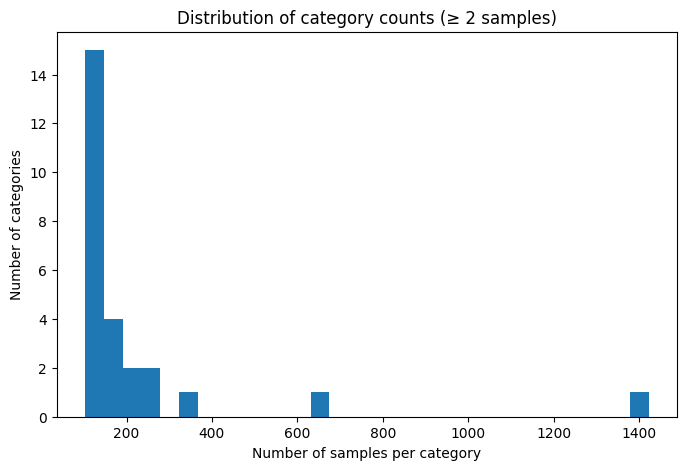

In [ ]:
# count categories
counts = df['actual_proc_1_procedure_code'].value_counts()

# keep categories with at least 2 samples
counts_filtered = counts[counts > 100]

# plot histogram
plt.figure(figsize=(8, 5))
plt.hist(counts_filtered, bins=30)
plt.xlabel('Number of samples per category')
plt.ylabel('Number of categories')
plt.title('Distribution of category counts (≥ 2 samples)')
plt.show()

In [ ]:
counts_filtered

,count
actual_proc_1_procedure_code,
S069,1423
R172,633
Y808,326
K636,278
R182,259
...,...
A263,11
Z681,11
Z765,11


In [ ]:
categorical_cols_features = list(df.select_dtypes(include="object").columns)
categorical_cols_features

['TheatreRoom',
 'admission_type',
 'SessionIDdesc',
 'actual_proc_1_procedure_code',
 'ProcedureDescription',
 'theatre_notes',
 'into_theatre',
 'anaesthetic_start_time',
 'incision',
 'closure',
 'out_of_theatre',
 'operation_end_time',
 'PriorityLevelCode',
 'anaesthetic_desc',
 'listing_cons_code',
 'theat_surg_1_national_code',
 'theat_anae_1_national_code',
 'extracted_words']

In [ ]:
df['admission_type']

,admission_type
0,0
1,0
2,0
3,0
4,0
...,...
14913,4
14914,0
14915,0
14916,0


In [ ]:
TAndO=["Trauma and Orthopaedics", "Trauma & Orthopaedics", "Trauma & Ortho", "Trauma and Ortho", "Trauma Orthopaedics", "Trauma and Orthop", "Trauma  Orthopaedics", "3SD) Khan Trauma and Orthopaedics", " Orthopaedics" , "Orthopaedics","PM/EVE) Mr A Porteous Trauma & Orthopaedics"]
df.loc[df['extracted_words'].isin(TAndO), 'extracted_words'] = 'T&O'

In [ ]:
Plastic=["Plastic Surgery"]
df.loc[df['extracted_words'].isin(Plastic), 'extracted_words'] = 'Plastic surgery'

In [ ]:
NonSpecific=["Non-Specific"]
df.loc[df['extracted_words'].isin(NonSpecific), 'extracted_words'] = 'Non Specific'

In [ ]:
Neurology=["Neurology","Neurosurgery"]
df.loc[df['extracted_words'].isin(Neurology), 'extracted_words'] = 'Neuro'

In [ ]:
ObsGynae=["Obstetrics","Obstetrics ","Gynaecology","Obs & Gynae","Obstetrics and Gynaecology"]
df.loc[df['extracted_words'].isin(ObsGynae), 'extracted_words'] = 'Obs&Gynae'

In [ ]:
general=["General Surgery","general surgery ","General","general surgery"]
df.loc[df['extracted_words'].isin(general), 'extracted_words'] = 'general'

In [ ]:
Breast=["Breast Surgery"]
df.loc[df['extracted_words'].isin(Breast), 'extracted_words'] = 'Breast'

In [ ]:
ColoRectal=["Colorectal Surgery"]
df.loc[df['extracted_words'].isin(ColoRectal), 'extracted_words'] = 'Colo-Rectal'

In [ ]:
Urology=["Reg List, Overseen by C.Burt A.Smith"]#Haemorrhoidectomy NOTE
df.loc[df['extracted_words'].isin(Urology), 'extracted_words'] = 'Urology'

In [ ]:
VascularSurgery=["Vascular/Gynae Surgery"]
df.loc[df['extracted_words'].isin(VascularSurgery), 'extracted_words'] = 'Vascular Surgery'

In [ ]:
#Endo=["3SD"]# row numbers4268 /1286
#df.loc[df['extracted_words'].isin(Endo), 'extracted_words'] = 'Renal / endo'

In [ ]:
#Breast=["Breast Surgery"]
#df.loc[df['extracted_words'].isin(Breast), 'extracted_words'] = 'Breast'

In [ ]:
tsd# row numbers ( 7464 /7533 vascular) ( 4562 / 5566 General Surgery)

['TH17 (2SD) J Hewes General Surgery',
 'TH17 (2SD) J Hewes General Surgery',
 'TH19 (2SD) CEPOD',
 'TH19 (2SD) CEPOD']

In [ ]:
df['extracted_words'].value_counts()

,count
extracted_words,
Plastic surgery,2763
T&O,2245
Radiology,1989
Obs&Gynae,1935
Urology,1503
Non Specific,1451
Cardiology,684
Neuro,542
general,431


0                   [Plastic Surgery]
1                           [Urology]
2           [Trauma and Orthopaedics]
6                         [Radiology]
10                     [Neurosurgery]
13                      [Gynaecology]
18            [Trauma & Orthopaedics]
19                     [Non Specific]
23                              [T&O]
24                   [Breast Surgery]
31                 [Vascular Surgery]
39                  [Plastic surgery]
42                      [Obs & Gynae]
46                       [Cardiology]
60                  [General Surgery]
90                    [ Orthopaedics]
91                       [Nephrology]
128                      [Bariatrics]
130                              None
198                    [Anaesthetics]
199          [Thoracic & Respiratory]
336                     [Dermatology]
355              [Colorectal Surgery]
365                        [Upper GI]
575                           [Renal]
965            [Trauma  Orthopaedics]
1298        

In [ ]:
df.drop(columns=['recovery_time','theat_anae_1_national_code','TheatreRoom','anaesthetic_desc','incision','closure', 'theat_surg_1_national_code'], inplace=True)

In [ ]:
labelEncoder= LabelEncoder()
df['admission_type'] = labelEncoder.fit_transform(df['admission_type'].astype(str))